In [274]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [275]:
df = pd.read_csv("/content/drive/MyDrive/Machine Learning Tutorial/Machine Learning/Practice Task/Customer_segmentation/smartcart_customers.csv")

In [276]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [277]:
df.shape

(2240, 22)

In [278]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [279]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


# Data Preprocessing

### handle Missing Values


In [280]:
df['Income'] = df['Income'].fillna(df["Income"].median())

In [281]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [282]:
df.isnull().sum().sum()

np.int64(0)

## Feature Engineering

In [283]:
# add new feature **Age**, remove birth year
df["Age"] = 2026 - df["Year_Birth"]

In [284]:
# customer joining Date

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

refrence_date = df["Dt_Customer"].max()

df["Customer_Tenure_Date"] = (refrence_date - df["Dt_Customer"]).dt.days

In [285]:
# Total spending

df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [286]:
# Total Child

df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [287]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Date,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [288]:
# Education
# convert into three catogaries : Graduate, Postgraduate, Undergraduate

df["Education"] = df["Education"].replace(
    {
        "Basic":"Undergraduate",
        "2n Cycle":"Undergraduate",
        "Graduation":"Graduate",
        "Master":"Postgraduate",
        "PhD":"Postgraduate"
    }
)

print(df["Education"].value_counts())

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64


In [289]:
# Marital_Status

df["Living_With"] = df["Marital_Status"].replace(
    {
        "Married" : "Together",
        "Single" : "Alone" ,
        "Divorced" : "Alone",
        "Widow" : "Alone",
        "Together" : "Together",
        "Absurd" : "Alone",
        "YOLO" : "Alone"
    }
)
df["Living_With"].value_counts()

,count
Living_With,
Together,1444
Alone,796


In [290]:
# drop Columns

drop_cols = ['ID', 'Year_Birth', 'Marital_Status', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']

df_cleaned = df.drop(columns=drop_cols)

In [291]:
df_cleaned.shape

(2240, 15)

# outliers

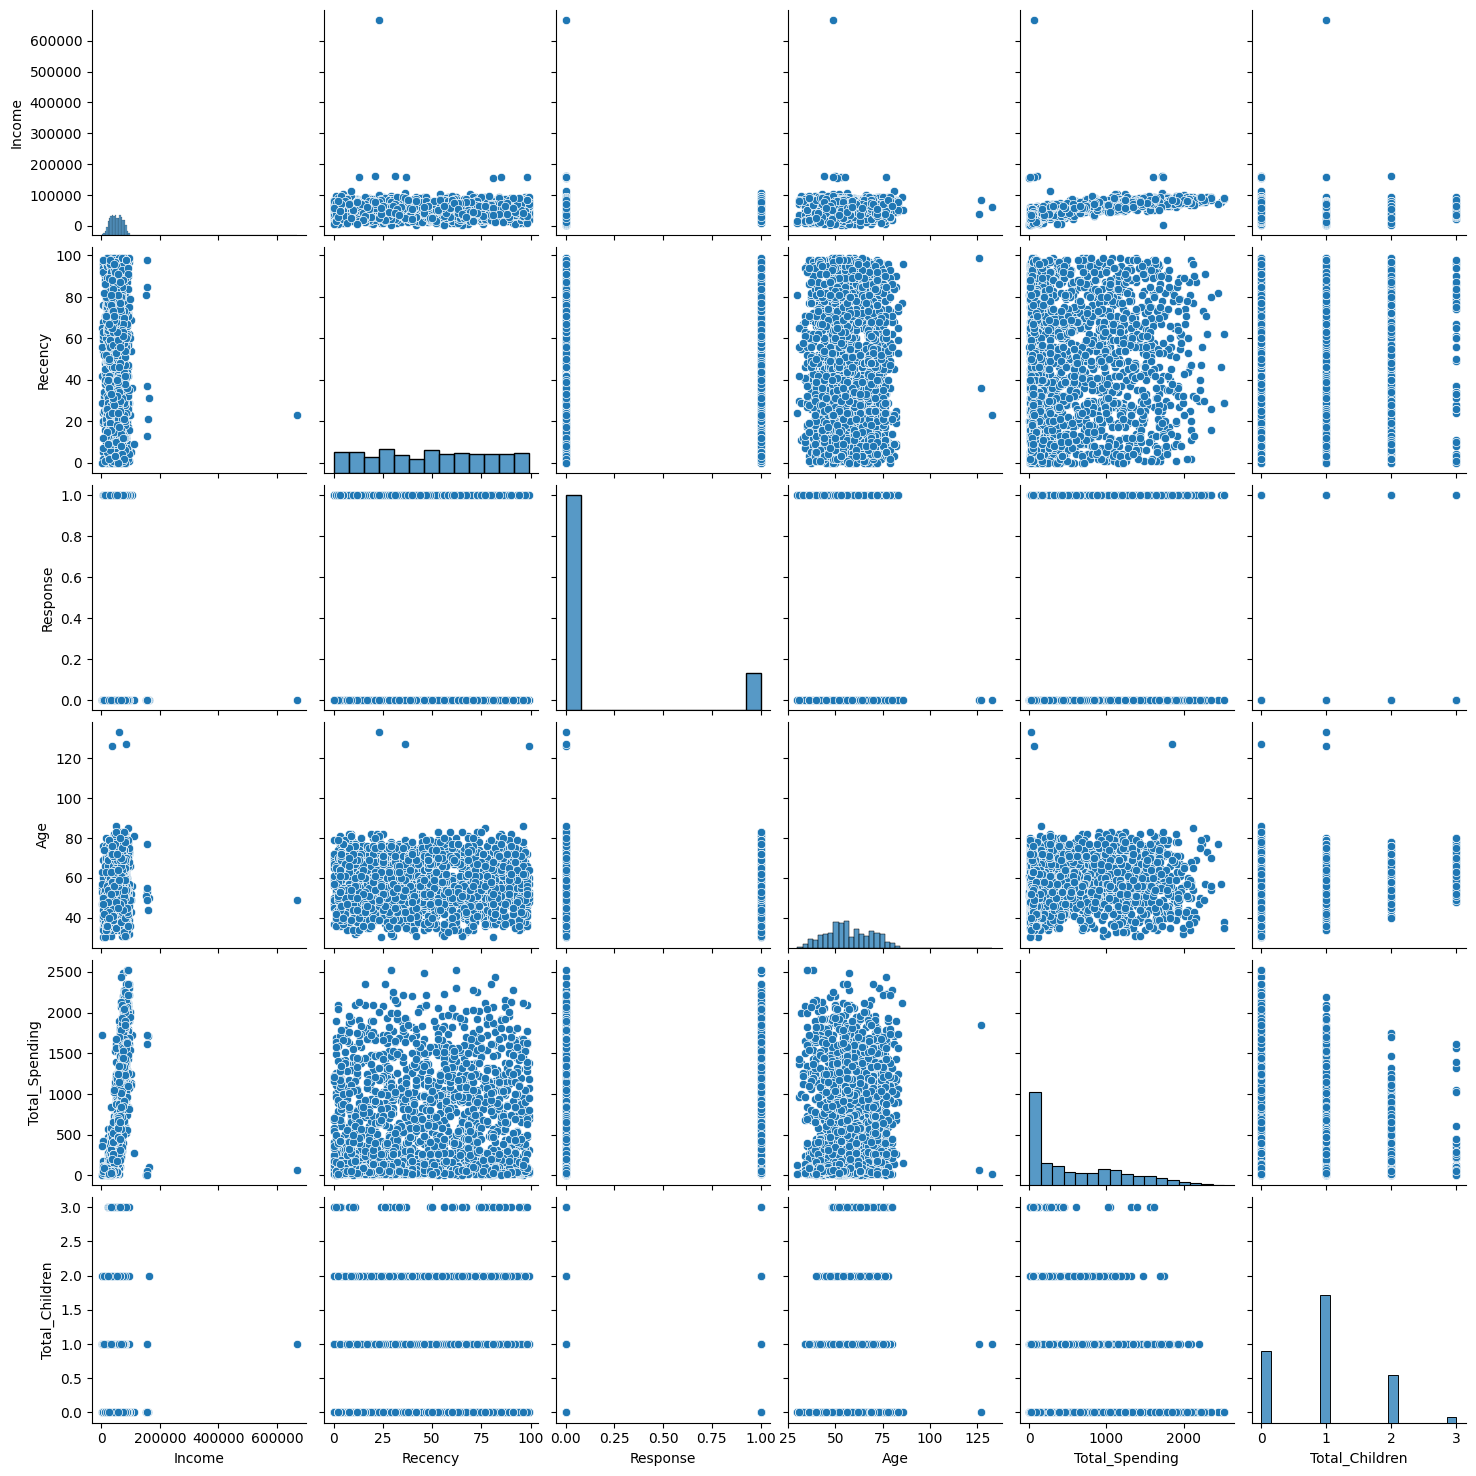

In [292]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

sns.pairplot(df_cleaned[cols])

In [293]:
# remove outlier
print("data size with outlier : ",len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"] <= 90)]
df_cleaned = df_cleaned[ (df_cleaned["Income"] <= 600000)]

print("data size without outlier : ",len(df_cleaned))

data size with outlier :  2240
data size without outlier :  2236


# HeatMap


<Axes: >

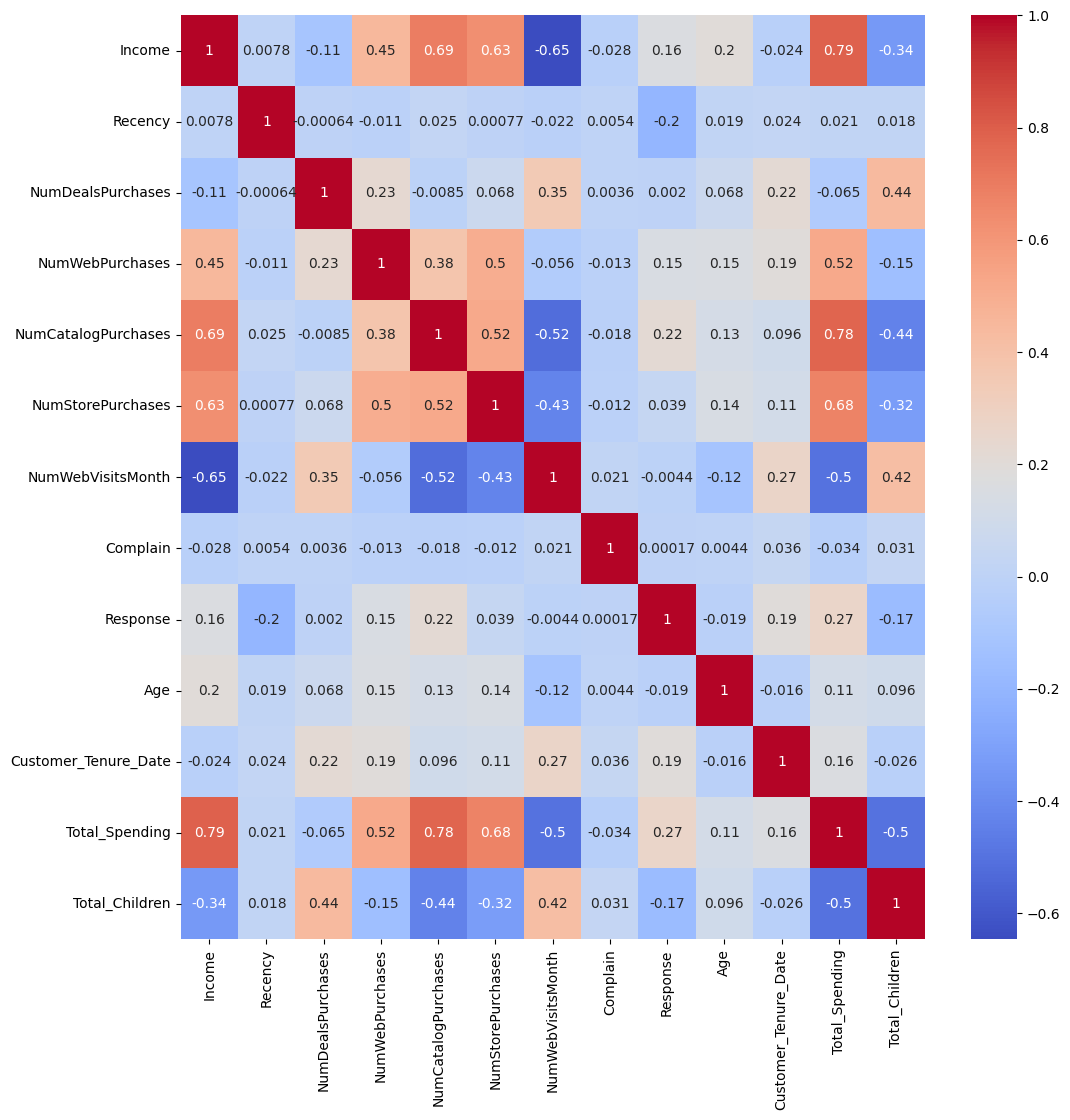

In [294]:
corr = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(12,12))
sns.heatmap(corr, annot=True, cmap="coolwarm")

# Feature Encoding

In [295]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [296]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index =df_cleaned.index)

In [297]:
enc_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2236 entries, 0 to 2239
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Education_Graduate       2236 non-null   float64
 1   Education_Postgraduate   2236 non-null   float64
 2   Education_Undergraduate  2236 non-null   float64
 3   Living_With_Alone        2236 non-null   float64
 4   Living_With_Together     2236 non-null   float64
dtypes: float64(5)
memory usage: 104.8 KB


In [298]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols) , enc_df], axis=1)

In [299]:
df_encoded.shape

(2236, 18)

In [300]:
X = df_encoded

# Scaling

In [301]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Data Visualization

In [302]:
X_scaled.shape

(2236, 18)

In [303]:
from sklearn.decomposition import PCA

In [304]:
# 2D

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [305]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

Text(0.5, 1.0, '2D PCA')

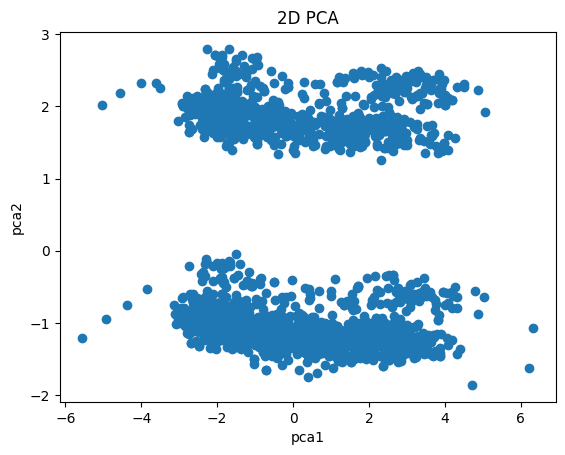

In [306]:
plt.scatter(x=X_pca[:,0], y=X_pca[:,1])
plt.xlabel("pca1")
plt.ylabel("pca2")
plt.title("2D PCA")

In [307]:
# 3D
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D PCA')

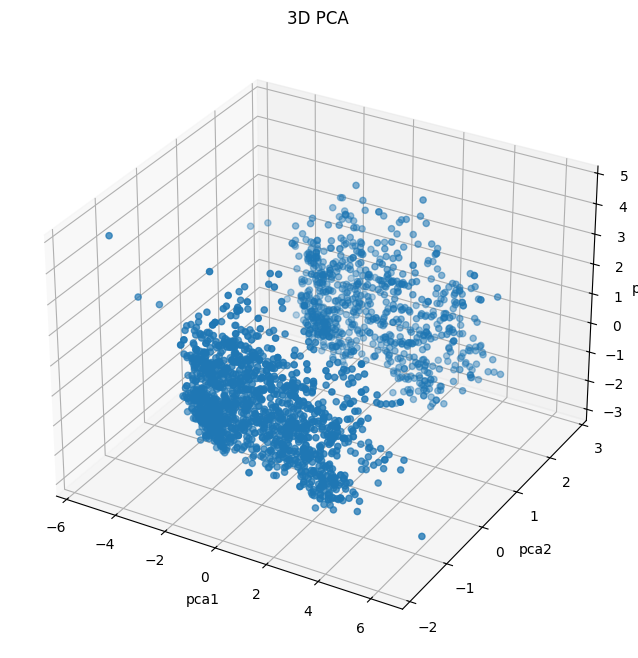

In [308]:
fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(projection='3d')

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])
ax.set_xlabel("pca1")
ax.set_ylabel("pca2")
ax.set_zlabel("pca3")
ax.set_title("3D PCA")

# Clustering

### K-Means

Analyze K value

1. Elbow Method

In [309]:
!pip install kneed

In [310]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []

for k in range(1,11):
  kmeans = KMeans(n_clusters = k, random_state=42)
  kmeans.fit_predict(X_pca)
  wcss.append(kmeans.inertia_)

In [311]:
knee = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k = knee.elbow

In [312]:
print("best k : ",optimal_k)

best k :  4


Text(0, 0.5, 'WCSS')

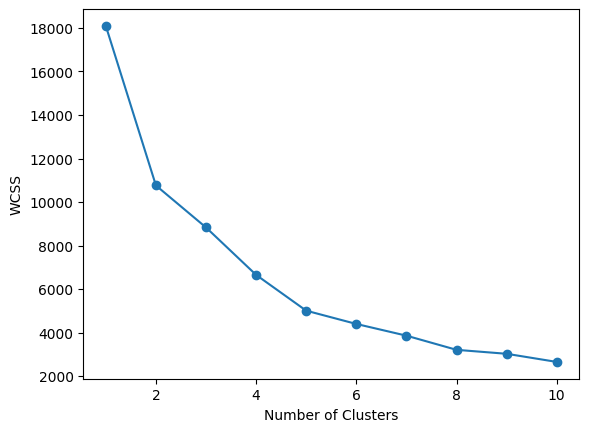

In [313]:
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

2. Silhouette Score

In [314]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
  kmeans = KMeans(n_clusters = k, random_state=42)
  labels = kmeans.fit_predict(X_pca)
  score = silhouette_score(X_pca, labels)
  scores.append(score)

Text(0, 0.5, 'Silhouette Score')

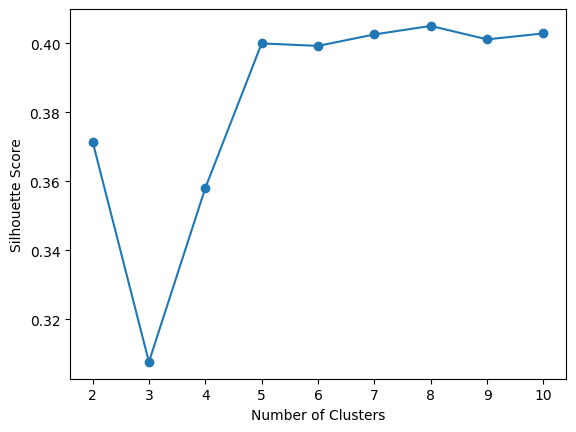

In [315]:
plt.plot(range(2,11),scores,marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

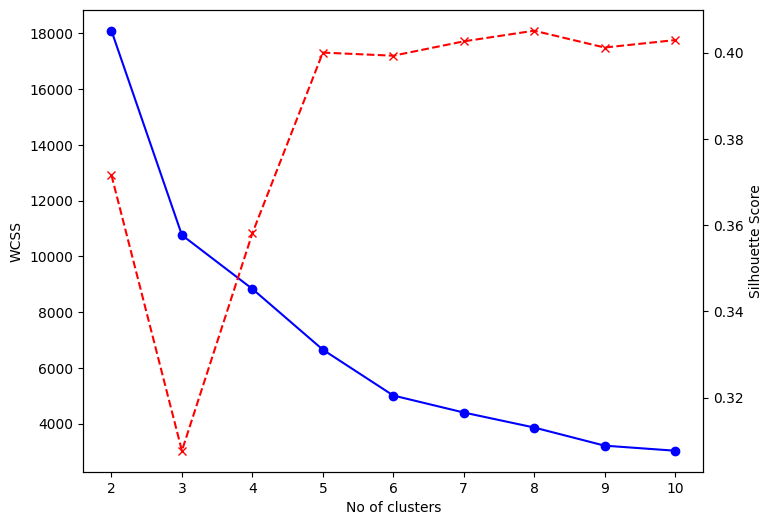

In [316]:
# combine plot

k_range = range(2,11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)],marker="o",color= "blue")
ax1.set_xlabel("No of clusters")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range,scores,marker="x",color="red",linestyle="--")
ax2.set_ylabel("Silhouette Score")

plt.show()

In [317]:
# KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

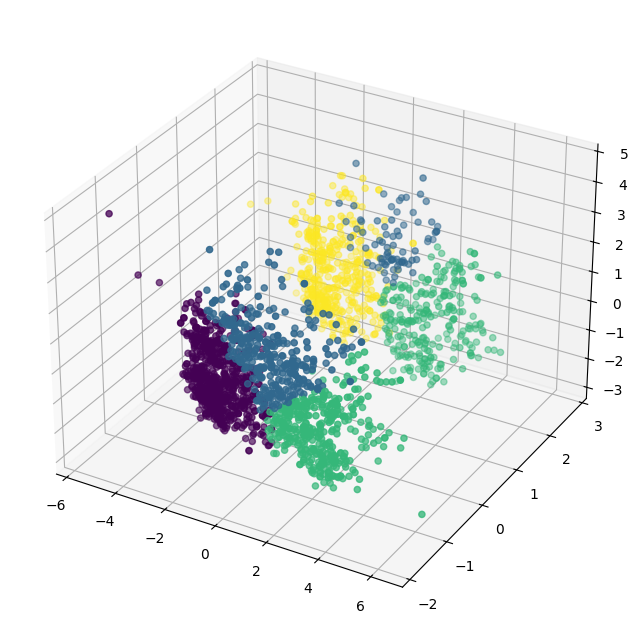

In [318]:
fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(projection='3d')

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2],c=labels_kmeans)

## AgglomerativeClustering ( hierarchical )

In [319]:
from sklearn.cluster import  AgglomerativeClustering

In [320]:
agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")

labels_agg = agg_clf.fit_predict(X_pca)

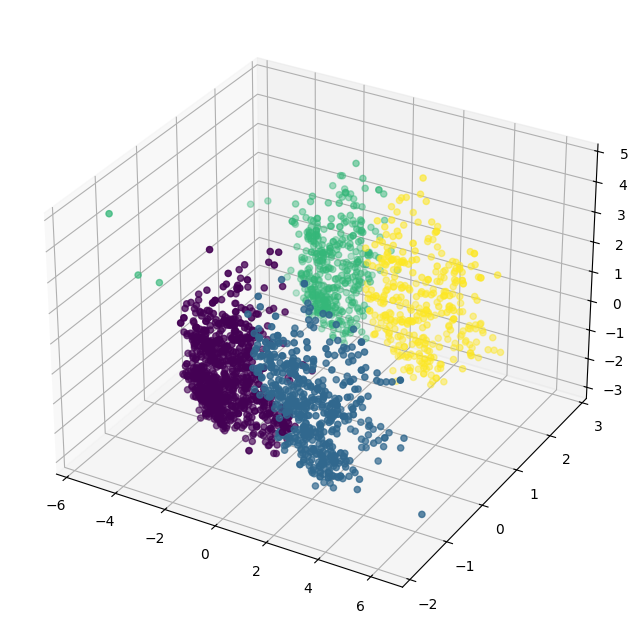

In [321]:
fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(projection='3d')

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2],c=labels_agg)

# Characterization of Clusters

In [322]:
X["clusters"] = labels_agg

In [323]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Date,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Together,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='clusters', ylabel='count'>

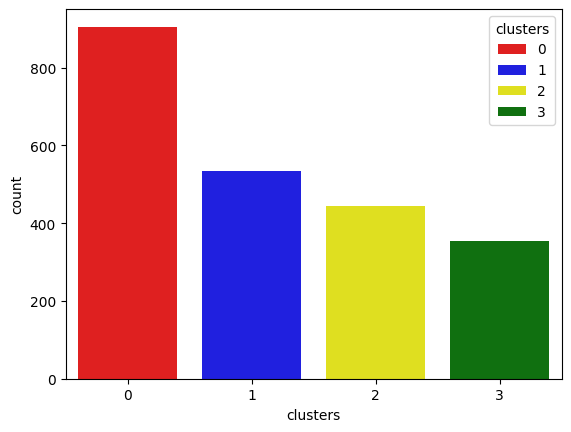

In [324]:
pal = ["red","blue","yellow","green"]

sns.countplot(x=X["clusters"],palette=pal,hue =X["clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

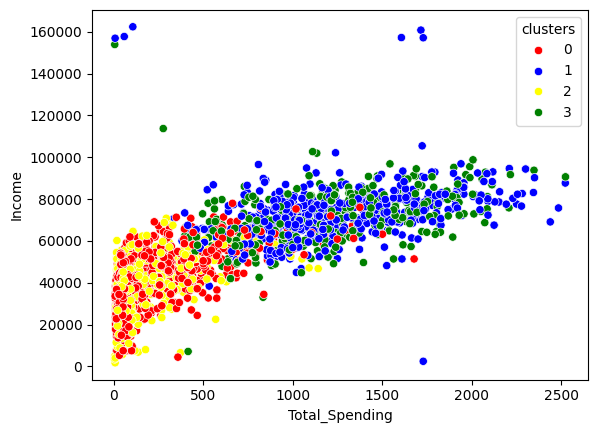

In [325]:
# Income & Spending , Patterns

sns.scatterplot(x=X["Total_Spending"],y=X["Income"],hue=X["clusters"],palette=pal)

In [326]:
# Analyze : Income & Spending

# cluster - 0 (red)
# low-modrate Income
# low-modrate spending

# cluster - 1 (blue)
# high Income
# high spending

# cluster - 3 (yellow)
# low Income
# low spending

# cluster - 4 (green)
# modrate-high Income
# high spending

In [327]:
 ##           -- Cluster Summary --

cluster_summary = X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_Tenure_Date  Total_Spending  \
clu

In [328]:
##  --- Data Analyze ---

#  give some basic analyze example !!

# cluster-0

# - more children
# - poor response
# - partners
# - high web visitor

# --------------------------------------------------------------------

# cluster-1

# - less children
# - slightly Age
# - avg response
# - partners
# - low web visitor
#                  |
# --------------------------------------------------------------------

# cluster-2

# - more children
# - avg response
# - Alone
# - high web visitor

# --------------------------------------------------------------------

# cluster-3

# - less children
# - slightly high Age
# - good response
# - Alone
# - low web visitor